<h1>NER Implementation</h1>

<h3>To use GLiNER model we need to install gliner==0.1.12. After doing it we can proceed to run the training script.

In my code I found out the best NER model to train is: https://huggingface.co/numind/NuNER_Zero
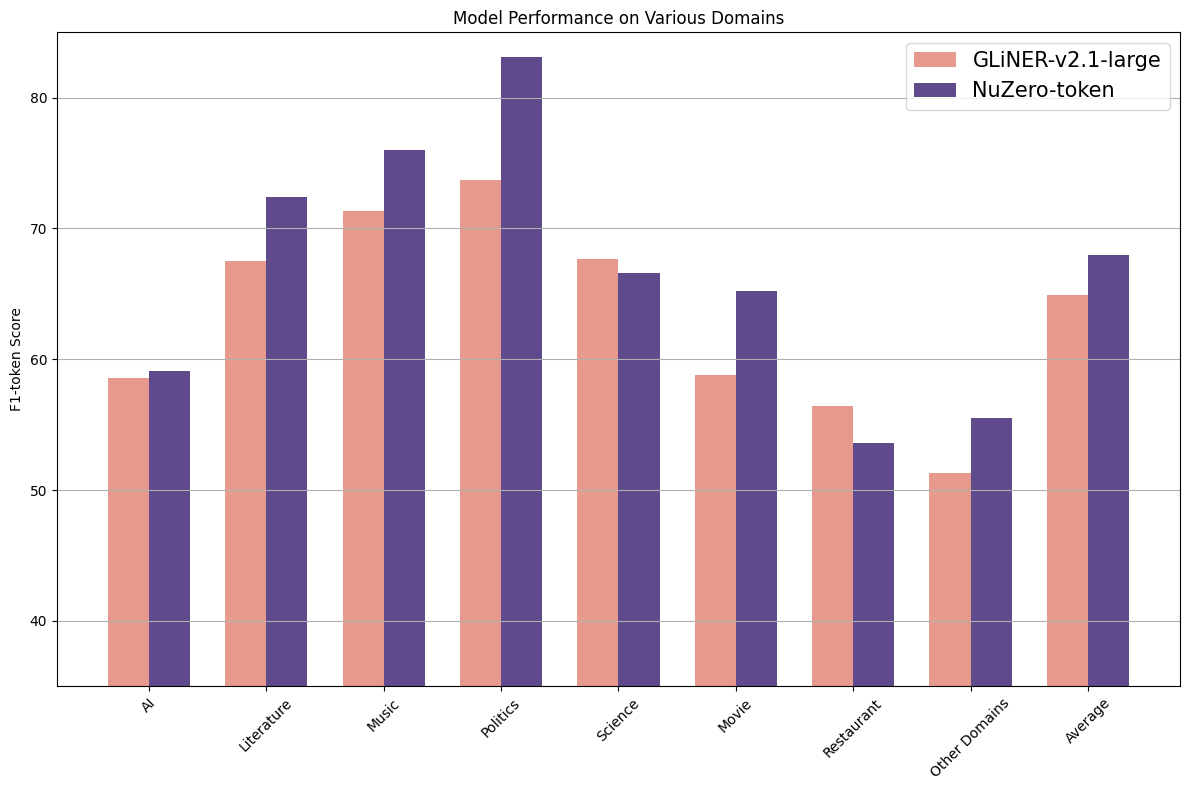

From the image above we can see the difference between the NuZero and the GLiNERv2.1-Large.</h3>
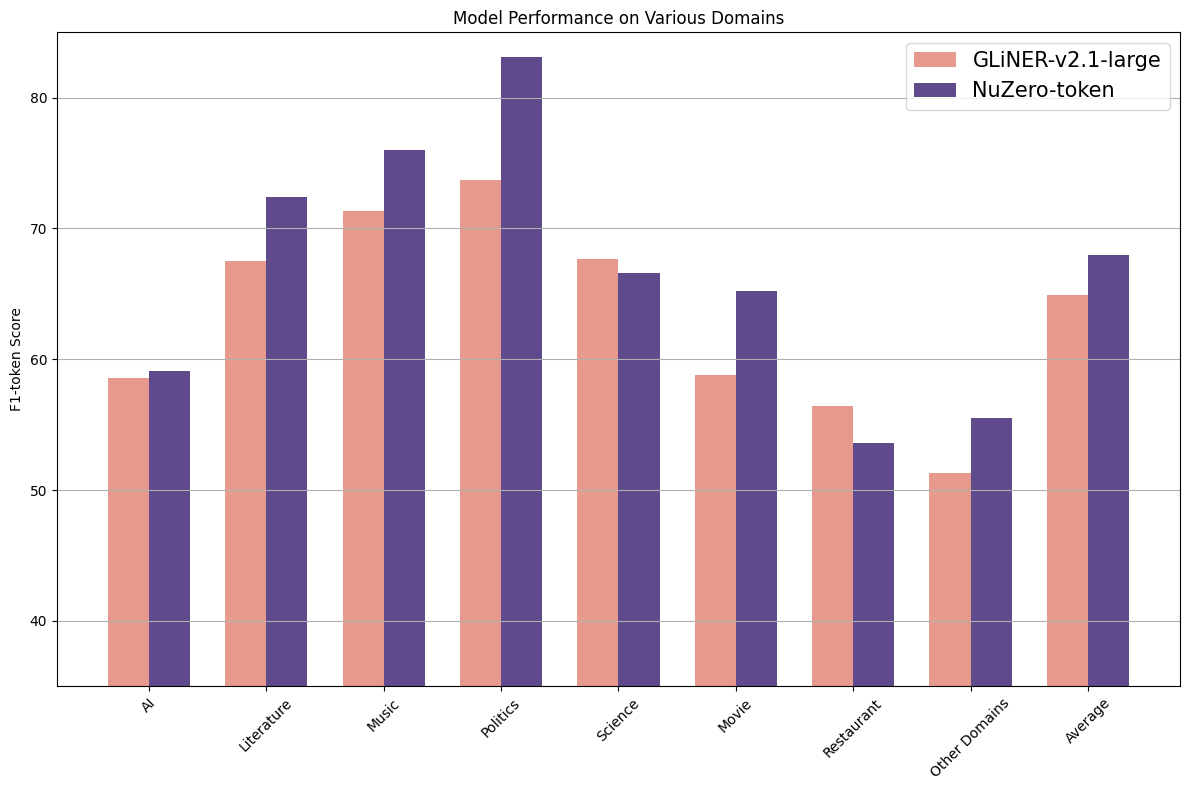

In [1]:
!pip install gliner==0.1.12

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 19.3 MB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.3/388.3 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.4/38.4 MB 46.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 7.0 MB/s eta 0:00:00
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16161 sha256=d5d13749404dadf975ff92299037aadae10b4ca93aab729eb7d

<h1>The Code to Train the NER Model</h1>

In [3]:
import json
import os
import torch
from tqdm import tqdm
from gliner import GLiNER
from types import SimpleNamespace
from transformers import AutoTokenizer, get_cosine_schedule_with_warmup
from sklearn.model_selection import train_test_split
from torch.nn import CrossEntropyLoss
import unittest

# --------------------------------------------------
# 1. Load the JSON data from the file
# --------------------------------------------------
with open("/kaggle/input/merged/merged_dataset.json", "r") as f:
    articles = json.load(f)
# --------------------------------------------------
# 2. Initialize the tokenizer
# --------------------------------------------------
tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-large")

# --------------------------------------------------
# 3. Preprocess and convert character-level entity spans to token-level spans
#    using both title and abstract.
# --------------------------------------------------
def preprocess_data(articles):
    processed_data = []
    for article_id, article_info in articles.items():
        # Extract title and abstract from the metadata.
        title_text = article_info["metadata"]["title"]
        abstract_text = article_info["metadata"]["abstract"]
        
        # Combine title and abstract with a space separator.
        combined_text = title_text + " " + abstract_text
        
        # Tokenize the combined text with offset mappings (do not add special tokens)
        encoding = tokenizer(combined_text, return_offsets_mapping=True, add_special_tokens=False)
        tokenized_text = tokenizer.convert_ids_to_tokens(encoding["input_ids"])
        offset_mapping = encoding["offset_mapping"]

        new_ner = []
        # Process each entity from either title or abstract.
        for ent in article_info["entities"]:
            # Only consider entities from the title or abstract.
            if ent["location"] not in ["title", "abstract"]:
                continue

            start_char = ent["start_idx"]
            end_char = ent["end_idx"]
            label = ent["label"].lower()

            # If the entity is from the abstract, adjust offsets by length of title + 1 (for the space).
            if ent["location"] == "abstract":
                offset_adjust = len(title_text) + 1
                start_char += offset_adjust
                end_char += offset_adjust

            # For each token, if its character span overlaps with the entity span, mark it.
            for idx, (token_start, token_end) in enumerate(offset_mapping):
                if token_end > start_char and token_start < end_char:
                    new_ner.append((idx, idx, label))
        
        processed_data.append({
            "tokenized_text": tokenized_text,
            "ner": new_ner,
        })
    return processed_data

processed_data = preprocess_data(articles)
model = GLiNER.from_pretrained("numind/NuNerZero")

# --------------------------------------------------
# 4. Split data into training, validation, and test sets (if desired)
# --------------------------------------------------
train_data, val_data = train_test_split(processed_data, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(val_data, test_size=0.5, random_state=42)

# --------------------------------------------------
# 5. Define hyperparameters and training configuration
# --------------------------------------------------
config = SimpleNamespace(
    num_steps=10000,            # 1500 Platinum, 2500 Gold, 6000 Silver, 10000 Bronze
    eval_every=2500,            # 100 Platinum, 250 Gold, 400 Silver, 1500 Bronze
    train_batch_size=2,
    max_len=600,                # 256 or 356
    device='cuda',
    warmup_ratio=0.1,
    lr_encoder=1e-5,
    lr_others=5e-5,
    freeze_token_rep=True,
    max_types=25,
    shuffle_types=True,
    random_drop=True,
    max_neg_type_ratio=1,
)

# --------------------------------------------------
# 6. Training function (without saving logs/checkpoints during training)
# --------------------------------------------------
def train(model, config, train_data, eval_data=None):
    model = model.to(config.device)

    # Set sampling parameters.
    model.set_sampling_params(
        max_types=config.max_types,
        shuffle_types=config.shuffle_types,
        random_drop=config.random_drop,
        max_neg_type_ratio=config.max_neg_type_ratio,
        max_len=config.max_len
    )

    model.train()
    train_loader = model.create_dataloader(train_data, batch_size=config.train_batch_size, shuffle=True)
    optimizer = model.get_optimizer(config.lr_encoder, config.lr_others, config.freeze_token_rep)
    pbar = tqdm(range(config.num_steps))
    num_warmup_steps = int(config.num_steps * config.warmup_ratio) if config.warmup_ratio < 1 else int(config.warmup_ratio)
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=config.num_steps
    )

    iter_train_loader = iter(train_loader)
    for step in pbar:
        try:
            batch = next(iter_train_loader)
        except StopIteration:
            iter_train_loader = iter(train_loader)
            batch = next(iter_train_loader)

        # Move batch tensors to the device.
        for k, v in batch.items():
            if isinstance(v, torch.Tensor):
                batch[k] = v.to(config.device)

        loss = model(batch)  # Forward pass.
        if torch.isnan(loss):
            continue

        loss.backward()       # Backpropagation.
        optimizer.step()      # Update parameters.
        scheduler.step()      # Update learning rate.
        optimizer.zero_grad() # Reset gradients.

        description = f"step: {step} | epoch: {step // len(train_loader)} | loss: {loss.item():.2f}"
        pbar.set_description(description)

        # Evaluate periodically
        if (step + 1) % config.eval_every == 0 and eval_data is not None:
            model.eval()
            results, f1 = model.evaluate(
                eval_data["samples"],
                flat_ner=True,
                threshold=0.5,
                batch_size=12,
                entity_types=eval_data["entity_types"]
            )
            print(f"Step={step}\n{results}")
            model.train()

# --------------------------------------------------
# 7. Setup evaluation data
# --------------------------------------------------
unique_labels = list({label for d in processed_data for (_, _, label) in d["ner"]})
eval_data = {
    "entity_types": unique_labels,
    "samples": processed_data[:10]
}

# --------------------------------------------------
# 8. Train the model and save the final trained model
# --------------------------------------------------
train(model, config, processed_data, eval_data)
model.save_pretrained("NuZero_merged_v1")

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/580 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/1.80G [00:00<?, ?B/s]

...

Step=4999
P: 69.81%	R: 80.07%	F1: 74.59%



step: 7499 | epoch: 21 | loss: 62.83:  75%|███████▌  | 7500/10000 [45:18<34:39,  1.20it/s]   

Step=7499
P: 70.48%	R: 80.92%	F1: 75.34%



step: 9999 | epoch: 29 | loss: 84.04: 100%|██████████| 10000/10000 [1:00:31<00:00,  2.75it/s]

Step=9999
P: 68.98%	R: 79.71%	F1: 73.96%



<h2>Code to use to test the NER with platinum, merged, gold, silver etc without annotations:<h2>

In [2]:
import json
import os
from gliner import GLiNER

# This function is used to merge adjacent entities given the text context.
def merge_entities(entities, text):
    if not entities:
        return []
    merged = []
    #sort entities by start index
    entities = sorted(entities, key=lambda e: e['start'])
    current = entities[0]
    for next_entity in entities[1:]:
        # if the next entity is immediately adjacent to current (allowing a space)
        if next_entity['label'] == current['label'] and (next_entity['start'] == current['end'] or next_entity['start'] == current['end'] + 1):
            # update text_span from current start to next_entity end
            current['text'] = text[current['start']: next_entity['end']].strip()
            current['end'] = next_entity['end']
        else:
            merged.append(current)
            current = next_entity
    merged.append(current)
    return merged

# Load model
model_path = "/kaggle/input/m/gennarofalter/merged/pytorch/default/1"
model = GLiNER.from_pretrained(model_path)

# Labels that the model should use
labels = ["biomedical technique", "microbiome", "ddf", "anatomical location",
          "dietary supplement", "food", "chemical", "bacteria", "human"]
labels = [l.lower() for l in labels]

def process_article(article_data):
    combined_entities = []
    for section in ["title", "abstract"]:
        text = article_data.get("metadata", {}).get(section, "")
        if not text:
            continue
        entities = model.predict_entities(text, labels)
        merged = merge_entities(entities, text)
        for ent in merged:
            # Remove the score if it exists.
            ent.pop("score", None)
            label_value = ent.pop("label")
            if label_value.lower() == "ddf":
                label_value = label_value.upper()
            # Create a new dictionary with keys in the desired order.
            new_ent = {
                "start_idx": ent.pop("start"),
                "end_idx": ent.pop("end") - 1,
                "location": section,
                "text_span": ent.pop("text"),
                "label": label_value
            }
            combined_entities.append(new_ent)
    return combined_entities

def process_articles(input_filepath, output_filepath=None):
    # Load articles JSON file
    with open(input_filepath, "r", encoding="utf-8") as f:
        articles = json.load(f)
    
    output = {}
    for article_id, article_data in articles.items():
        entities = process_article(article_data)
        output[article_id] = {
            "entities": entities
        }
    if output_filepath:
        with open(output_filepath, "w", encoding="utf-8") as fout:
            json.dump(output, fout, indent=4, ensure_ascii=False)
        print(f"Output saved to {output_filepath}")
    return output

input_file = r"/kaggle/input/d/gennarofalter/testdev/aug_dev_nothingv2.json"
output_file = r"/kaggle/working/merged_merged_augdev.json"

result = process_articles(input_file, output_file)

config.json not found in /kaggle/input/m/gennarofalter/merged/pytorch/default/1


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/580 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/874M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/gliner/model.py:420: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_file, map_location=torch.device(map_

Output saved to /kaggle/working/merged_merged_augdev.json


<h2>Code to use to test the NER with <strong>articles_dev</strong> or the future <strong>test_set</strong>.</h2>

In [7]:
import json
import os
from gliner import GLiNER

# This function is used to merge adjacent entities given the text context.
def merge_entities(entities, text):
    if not entities:
        return []
    merged = []
    # Sort entities by start index (if not already sorted)
    entities = sorted(entities, key=lambda e: e['start'])
    current = entities[0]
    for next_entity in entities[1:]:
        # If the next entity is immediately adjacent to current
        if next_entity['label'] == current['label'] and (next_entity['start'] == current['end'] or next_entity['start'] == current['end'] + 1):
            # Update text_span from current start to next_entity end
            current['text'] = text[current['start']: next_entity['end']].strip()
            current['end'] = next_entity['end']
        else:
            merged.append(current)
            current = next_entity
    merged.append(current)
    return merged

# Load the GLiNER model
model_path = "/kaggle/input/m/gennarofalter/merged/pytorch/default/1"
model = GLiNER.from_pretrained(model_path)

# List of labels that the model should use to perform NER
labels = ["biomedical technique", "microbiome", "ddf", "anatomical location",
          "dietary supplement", "food", "chemical", "bacteria", "human"]
labels = [l.lower() for l in labels]

def process_article(article_data):
    combined_entities = []
    for section in ["title", "abstract"]:
        # Access directly to the json file
        text = article_data.get(section, "")
        if not text:
            continue
        entities = model.predict_entities(text, labels)
        merged = merge_entities(entities, text)
        for ent in merged:
            # Remove the score if it exists.
            ent.pop("score", None)
            label_value = ent.pop("label")
            if label_value.lower() == "ddf":
                label_value = label_value.upper()
            # Create a new dictionary with keys in the desired order.
            new_ent = {
                "start_idx": ent.pop("start"),
                "end_idx": ent.pop("end") - 1,
                "location": section,
                "text_span": ent.pop("text"),
                "label": label_value
            }
            combined_entities.append(new_ent)
    return combined_entities

def process_articles(input_filepath, output_filepath=None):
    # Load articles JSON file
    with open(input_filepath, "r", encoding="utf-8") as f:
        articles = json.load(f)
    
    output = {}
    for article_id, article_data in articles.items():
        entities = process_article(article_data)
        output[article_id] = {
            "entities": entities
        }
    if output_filepath:
        with open(output_filepath, "w", encoding="utf-8") as fout:
            json.dump(output, fout, indent=4, ensure_ascii=False)
        print(f"Output saved to {output_filepath}")
    return output

input_file = r"/kaggle/input/articles-platinum/articles_train_platinum.json"
output_file = r"/kaggle/working/merged+silver_merged_platinum.json"

result = process_articles(input_file, output_file)

config.json not found in /kaggle/input/mergedaugbronze/pytorch/default/1


RuntimeError: PytorchStreamReader failed reading zip archive: failed finding central directory

<h1>Code to Evalaute the performance of the different NER models </h1>

In [5]:
import json
import os
import torch
from gliner import GLiNER
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# --------------------------------------------------
# 1. Load the test JSON data from "train_gold.json"
# --------------------------------------------------
with open("/kaggle/input/train-tratinum-json/train_platinum.json", "r", encoding="utf-8") as f:
    gold_articles = json.load(f)

# --------------------------------------------------
# 2. Initialize the tokenizer (using the same model as during training)
# --------------------------------------------------
tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-large")

# --------------------------------------------------
# 3. Preprocess test data: convert character-level entity spans to token-level spans
#    using both title and abstract.
# --------------------------------------------------
def preprocess_test_data(articles):
    processed_data = []
    for article_id, article_info in articles.items():
        # Extract title and abstract.
        title_text = article_info["metadata"]["title"]
        abstract_text = article_info["metadata"]["abstract"]
        
        # Combine title and abstract with a space separator.
        combined_text = title_text + " " + abstract_text
        
        # Tokenize the combined text with offset mappings (no special tokens).
        encoding = tokenizer(combined_text, return_offsets_mapping=True, add_special_tokens=False)
        tokenized_text = tokenizer.convert_ids_to_tokens(encoding["input_ids"])
        offset_mapping = encoding["offset_mapping"]

        new_ner = []
        # Process each entity (only from title or abstract).
        for ent in article_info["entities"]:
            if ent["location"] not in ["title", "abstract"]:
                continue

            start_char = ent["start_idx"]
            end_char = ent["end_idx"]
            label = ent["label"].lower()

            # If entity comes from abstract, adjust offsets by (len(title)+1).
            if ent["location"] == "abstract":
                offset_adjust = len(title_text) + 1
                start_char += offset_adjust
                end_char += offset_adjust

            # Convert character-level spans to token-level spans.
            for idx, (token_start, token_end) in enumerate(offset_mapping):
                if token_end > start_char and token_start < end_char:
                    new_ner.append((idx, idx, label))
        
        processed_data.append({
            "tokenized_text": tokenized_text,
            "ner": new_ner,
            "text": combined_text  # optionally keep the full text
        })
    return processed_data

test_data = preprocess_test_data(gold_articles)

# --------------------------------------------------
# 4. Extract unique entity labels from the test set.
# --------------------------------------------------
unique_labels = list({label for d in test_data for (_, _, label) in d["ner"]})

# --------------------------------------------------
# 5. Load two trained models (update paths accordingly)
# --------------------------------------------------
# For example, if you have two models saved in directories "ModelA" and "ModelB":
model_path1 = "/kaggle/input/silvera/pytorch/default/1"
model_path2 = "/kaggle/input/silverb/pytorch/default/1"
#model_path3 = "/kaggle/input/m/gennarofalter/merged/pytorch/default/1"
#model_path4 = "/kaggle/input/augmented/pytorch/default/1"
model1 = GLiNER.from_pretrained(model_path1)
model2 = GLiNER.from_pretrained(model_path2)
#model3 = GLiNER.from_pretrained(model_path3)
#model4 = GLiNER.from_pretrained(model_path4)

# Optionally, if running on GPU, you may want to move them to cuda:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model1 = model1.to(device)
model2 = model2.to(device)
#model3 = model3.to(device)
#model4 = model4.to(device)

# --------------------------------------------------
# 6. Evaluate each model on the test set.
# --------------------------------------------------
def evaluate_model(model, samples, entity_types, batch_size=12, threshold=0.5):
    # GLiNER.evaluate returns a results dictionary and an overall F1 score.
    results, f1 = model.evaluate(
        samples,
        flat_ner=True,
        threshold=threshold,
        batch_size=batch_size,
        entity_types=entity_types
    )
    return results, f1

results1, f1_1 = evaluate_model(model1, test_data, unique_labels)
results2, f1_2 = evaluate_model(model2, test_data, unique_labels)
#results3, f1_3 = evaluate_model(model3, test_data, unique_labels)
#results4, f1_4 = evaluate_model(model4, test_data, unique_labels)

# --------------------------------------------------
# 7. Print out the evaluation results.
# --------------------------------------------------
print("=== Model 1 Evaluation ===")
print("Results:", results1)
print("F1 Score:", f1_1)

print("\n=== Model 2 Evaluation ===")
print("Results:", results2)
print("F1 Score:", f1_2)

#print("\n=== Model 3 Evaluation ===")
#print("Results:", results3)
#print("F1 Score:", f1_3)

#print("\n=== Model 4 Evaluation ===")
#print("Results:", results4)
#print("F1 Score:", f1_4)


config.json not found in /kaggle/input/silvera/pytorch/default/1
config.json not found in /kaggle/input/silverb/pytorch/default/1
/usr/local/lib/python3.10/dist-packages/gliner/modules/base.py:33: UserWarning: Sentence of length 474 has been truncated to 284
  warnings.warn(f"Sentence of length {len(tokens)} has been truncated to {max_len}")
/usr/local/lib/python3.10/dist-packages/gliner/modules/base.py:33: UserWarning: Sentence of length 369 has been truncated to 284
  warnings.warn(f"Sentence of length {len(tokens)} has been truncated to {max_len}")
/usr/local/lib/python3.10/dist-packages/gliner/modules/base.py:33: UserWarning: Sentence of length 344 has been truncated to 284
  warnings.warn(f"Sentence of length {len(tokens)} has been truncated to {max_len}")
/usr/local/lib/python3.10/dist-packages/gliner/modules/base.py:33: UserWarning: Sentence of length 444 has been truncated to 284
  warnings.warn(f"Sentence of length {len(tokens)} has been truncated to {max_len}")
/usr/local/lib

=== Model 1 Evaluation ===
Results: P: 73.56%	R: 64.24%	F1: 68.58%

F1 Score: 0.6858305229912744

=== Model 2 Evaluation ===
Results: P: 71.32%	R: 58.64%	F1: 64.36%

F1 Score: 0.643627558881796


<h2>If you are using Kaggle to train the model, to download the trained model present in the output folder follow these steps:</h2>
<h3>
<ol>
<li> Put as tar file
<li> Download it using the display HTML. </li>
</ol>
</h3>

In [2]:
!tar -czvf RE_MERGEDSILVER_V0.tar.gz -C /kaggle/working RE_MERGEDSILVER_V0

RE_MERGEDSILVER_V0/
RE_MERGEDSILVER_V0/vocab.txt
RE_MERGEDSILVER_V0/config.json
RE_MERGEDSILVER_V0/model.safetensors
RE_MERGEDSILVER_V0/special_tokens_map.json
RE_MERGEDSILVER_V0/tokenizer_config.json
RE_MERGEDSILVER_V0/added_tokens.json


In [3]:
from IPython.display import HTML, display
display(HTML('<a href="RE_MERGEDSILVER_V0.tar.gz" download>Download RE_MERGEDSILVER_V0.tar.gz</a>'))

<h3>The NER model above is a test about the optimization of the one I used to train the merged model.
The difference between the first model and the newest is the adding of the CRF.
    <br>
Conditional random fields (CRFs) are a class of statistical modeling methods often applied in pattern recognition and machine learning and used for structured prediction. Whereas a classifier predicts a label for a single sample without considering "neighbouring" samples, a CRF can take context into account. [Definition Source: Wikipedia]
</h3>

<h2>The NER Optimized below has only been used to test new models but not for making predictions</h2>

In [12]:
#NER OPTIMIZED
import json
import random
import os
import torch
import torch.nn as nn
from tqdm import tqdm
from gliner import GLiNER
from types import SimpleNamespace
from transformers import AutoTokenizer, get_cosine_schedule_with_warmup
from sklearn.model_selection import train_test_split
from torchcrf import CRF  # pip install torchcrf

# --------------------------------------------------
# 1. Carica il dataset
# --------------------------------------------------
with open("/kaggle/input/merged/merged_dataset.json", "r", encoding="utf-8") as f:
    articles = json.load(f)

# --------------------------------------------------
# 2. Crea il mapping label2id e id2label dal dataset
# --------------------------------------------------
unique_labels = set()
for article_id, article_info in articles.items():
    for ent in article_info.get("entities", []):
        if ent["location"] in ["title", "abstract"]:
            unique_labels.add(ent["label"].lower())
unique_labels = sorted(list(unique_labels))
label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {idx: label for label, idx in label2id.items()}
print("Unique labels:", unique_labels)
print("Label2id:", label2id)

# --------------------------------------------------
# 3. Inizializza il tokenizer (stesso modello usato da GLiNER)
# --------------------------------------------------
tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-large")

# --------------------------------------------------
# 4. Preprocessa i dati: conversione degli span da carattere a token
#    e conversione della label in label id.
# --------------------------------------------------
def preprocess_data(articles, label2id):
    processed_data = []
    for article_id, article_info in articles.items():
        title_text = article_info["metadata"]["title"]
        abstract_text = article_info["metadata"]["abstract"]
        combined_text = title_text + " " + abstract_text
        
        # Tokenize
        encoding = tokenizer(
            combined_text,
            return_offsets_mapping=True,
            add_special_tokens=False
        )
        tokenized_text = tokenizer.convert_ids_to_tokens(encoding["input_ids"])
        offset_mapping = encoding["offset_mapping"]

        new_ner = []
        for ent in article_info.get("entities", []):
            if ent["location"] not in ["title", "abstract"]:
                continue

            start_char = ent["start_idx"]
            end_char = ent["end_idx"]
            # lowecase
            label = ent["label"].lower()
            # adjust offset if the entity comes from the abstract
            if ent["location"] == "abstract":
                offset_adjust = len(title_text) + 1
                start_char += offset_adjust
                end_char += offset_adjust

            for idx, (token_start, token_end) in enumerate(offset_mapping):
                if token_end > start_char and token_start < end_char:
                    # I used (idx, idx, label_id);
                    new_ner.append((idx, idx, label2id[label]))
        
        processed_data.append({
            "tokenized_text": tokenized_text,
            "ner": new_ner
        })
    return processed_data

processed_data = preprocess_data(articles, label2id)

# --------------------------------------------------
# 5. Model that uses the layer CRF
# --------------------------------------------------
class GLiNERWithCRF(nn.Module):
    def __init__(self, base_model, num_labels):
        super().__init__()
        self.gliner = base_model
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(self.gliner.config.hidden_size, num_labels)
        # Layer CRF, with batch_first=True
        self.crf = CRF(num_tags=num_labels, batch_first=True)
    
    def set_sampling_params(self, **kwargs):
        self.gliner.set_sampling_params(**kwargs)
    
    def create_dataloader(self, data, batch_size, shuffle=True, **kwargs):
        if shuffle:
            random.shuffle(data)
        return self.gliner.create_dataloader(data, batch_size=batch_size, **kwargs)

    def get_optimizer(self, lr_encoder, lr_others, freeze_token_rep):
        # Optimize
        optimizer = self.gliner.get_optimizer(lr_encoder, lr_others, freeze_token_rep)
        # Adding classifier parameters
        optimizer.add_param_group({"params": self.classifier.parameters(), "lr": lr_others})
        optimizer.add_param_group({"params": self.crf.parameters(), "lr": lr_others})
        return optimizer
    
    def forward(self, batch, labels=None):
        # Model forward
        outputs = self.gliner.forward(batch)
        sequence_output = outputs[0]
        sequence_output = self.dropout(sequence_output)
        logits = self.classifier(sequence_output)  # syntax: (batch, seq_len, num_labels)
        mask = batch.get("attention_mask", None)
        if labels is not None:
            loss = -self.crf(
                logits,
                labels,
                mask=mask.bool() if mask is not None else None,
                reduction="mean"
            )
            return loss
        else:
            best_tag_sequence = self.crf.decode(
                logits,
                mask=mask.bool() if mask is not None else None
            )
            return best_tag_sequence
            
    def evaluate(self, samples, flat_ner, threshold, batch_size, entity_types):
        # Base model
        return self.gliner.evaluate(
            samples,
            flat_ner=flat_ner,
            threshold=threshold,
            batch_size=batch_size,
            entity_types=entity_types
        )
    
    def save_pretrained(self, save_directory):
        os.makedirs(save_directory, exist_ok=True)
        torch.save(self.state_dict(), os.path.join(save_directory, "pytorch_model.bin"))

# --------------------------------------------------
# 6. Initialize Base Model
# --------------------------------------------------
base_model = GLiNER.from_pretrained("numind/NuNerZero")
num_labels = len(label2id)
model = GLiNERWithCRF(base_model, num_labels)

# --------------------------------------------------
# 7. Optional suddivision between the train test split
# --------------------------------------------------
train_data, val_data = train_test_split(processed_data, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(val_data, test_size=0.5, random_state=42)

# --------------------------------------------------
# 8. Hyperparameters definition
# --------------------------------------------------
config = SimpleNamespace(
    num_steps=10000,
    eval_every=200,
    train_batch_size=2,
    max_len=600,
    device='cuda',
    warmup_ratio=0.1,
    lr_encoder=1e-5,
    lr_others=5e-5,
    freeze_token_rep=True,
    max_types=25,
    shuffle_types=True,
    random_drop=True,
    max_neg_type_ratio=1,
)

# --------------------------------------------------
# 9. Training
# --------------------------------------------------
def train(model, config, train_data, eval_data=None):
    model = model.to(config.device)
    model.set_sampling_params(
        max_types=config.max_types,
        shuffle_types=config.shuffle_types,
        random_drop=config.random_drop,
        max_neg_type_ratio=config.max_neg_type_ratio,
        max_len=config.max_len
    )
    model.train()
    train_loader = model.create_dataloader(
        train_data,
        batch_size=config.train_batch_size,
        entity_types=unique_labels,  # Pass entity types here
        shuffle=True
    )
    optimizer = model.get_optimizer(config.lr_encoder, config.lr_others, config.freeze_token_rep)
    pbar = tqdm(range(config.num_steps))
    num_warmup_steps = int(config.num_steps * config.warmup_ratio) if config.warmup_ratio < 1 else int(config.warmup_ratio)
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=config.num_steps
    )
    iter_train_loader = iter(train_loader)
    for step in pbar:
        try:
            batch = next(iter_train_loader)
        except StopIteration:
            iter_train_loader = iter(train_loader)
            batch = next(iter_train_loader)
        # Sposta i tensori nel device
        for k, v in batch.items():
            if isinstance(v, torch.Tensor):
                batch[k] = v.to(config.device)
        labels = batch.get("labels", batch.get("ner"))
        loss = model(batch, labels=labels)
        if torch.isnan(loss):
            continue
        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        description = f"step: {step} | epoch: {step // len(train_loader)} | loss: {loss.item():.2f}"
        pbar.set_description(description)
        if (step + 1) % config.eval_every == 0 and eval_data is not None:
            model.eval()
            results, f1 = model.evaluate(
                eval_data["samples"],
                flat_ner=True,
                threshold=0.5,
                batch_size=12,
                entity_types=eval_data["entity_types"]
            )
            print(f"Step={step}\n{results}")
            model.train()

# --------------------------------------------------
# 10. Evaluation Data
# --------------------------------------------------
eval_data = {
    "entity_types": unique_labels,
    "samples": processed_data[:10]
}

# --------------------------------------------------
# 11. Ready to train the model
# --------------------------------------------------
train(model, config, processed_data, eval_data)
model.save_pretrained("NuZero_merged")


Unique labels: ['anatomical location', 'animal', 'bacteria', 'biomedical technique', 'chemical', 'ddf', 'dietary supplement', 'drug', 'food', 'gene', 'human', 'microbiome', 'statistical technique']
Label2id: {'anatomical location': 0, 'animal': 1, 'bacteria': 2, 'biomedical technique': 3, 'chemical': 4, 'ddf': 5, 'dietary supplement': 6, 'drug': 7, 'food': 8, 'gene': 9, 'human': 10, 'microbiome': 11, 'statistical technique': 12}


OutOfMemoryError: CUDA out of memory. Tried to allocate 502.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 10.12 MiB is free. Process 5084 has 14.73 GiB memory in use. Of the allocated memory 14.55 GiB is allocated by PyTorch, and 53.01 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)